print(px.data.carshare())
print(px.data.election())
print(px.data.gapminder())
print(px.data.iris())
print(px.data.tips())
print(px.data.wind())

In [2]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


# Parallel Sets/Coordinates

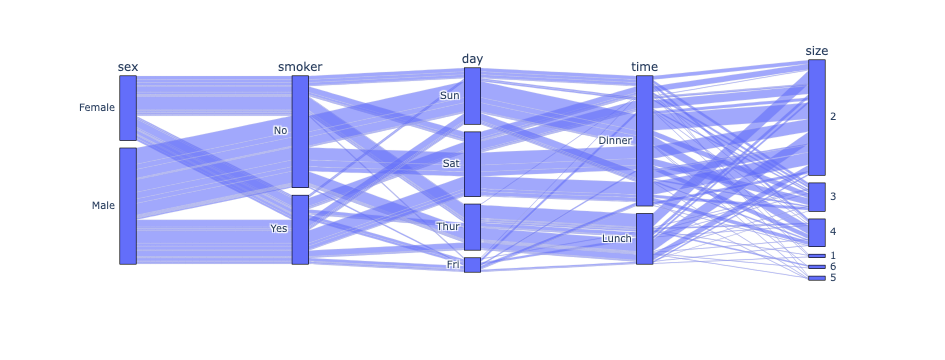

In [36]:
import plotly.express as px

df = px.data.tips()
fig = px.parallel_categories(df)

fig.show()

In [37]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


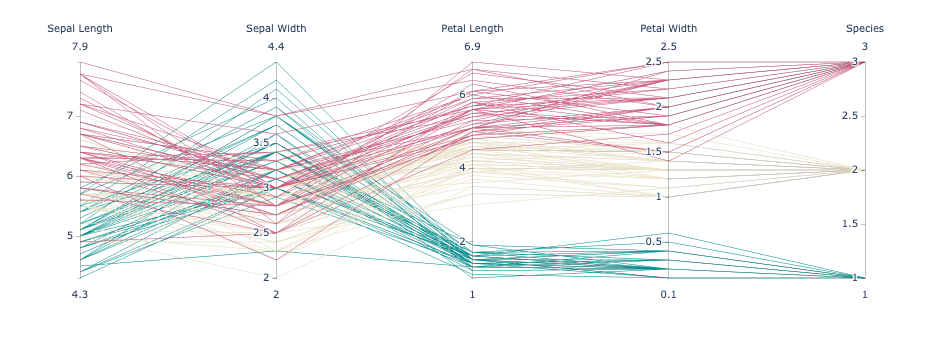

In [38]:
import plotly.express as px

df2 = px.data.iris()

fig = px.parallel_coordinates(
    df2, 
    color="species_id", 
    labels={"species_id": "Species",
            "sepal_width": "Sepal Width", 
            "sepal_length": "Sepal Length", 
            "petal_width": "Petal Width", 
            "petal_length": "Petal Length", },
    color_continuous_scale=px.colors.diverging.Tealrose,
    color_continuous_midpoint=2)

fig.update_layout(coloraxis_showscale=False)
fig.show()

In [39]:
df2
#df2.loc[80]

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,3
146,6.3,2.5,5.0,1.9,virginica,3
147,6.5,3.0,5.2,2.0,virginica,3
148,6.2,3.4,5.4,2.3,virginica,3


# Stream Graphs

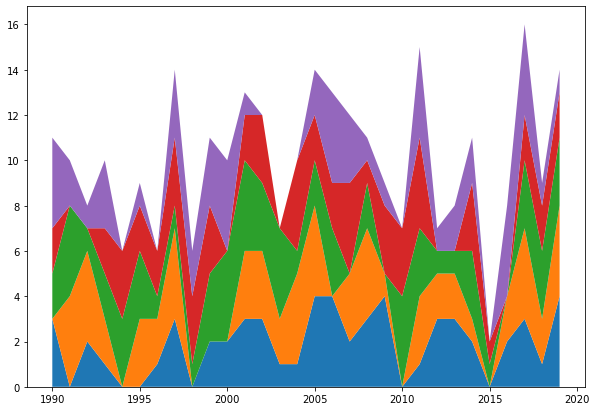

In [27]:
# Libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

x = np.arange(1990, 2020) # (N,) array-like

y = [np.random.randint(0, 5, size=30) for _ in range(5)] 

fig, ax = plt.subplots(figsize=(10, 7))
ax.stackplot(x, y);

In [41]:
#x
y

[array([3, 0, 2, 1, 0, 0, 1, 3, 0, 2, 2, 3, 3, 1, 1, 4, 4, 2, 3, 4, 0, 1,
        3, 3, 2, 0, 2, 3, 1, 4]),
 array([0, 4, 4, 2, 0, 3, 2, 4, 0, 0, 0, 3, 3, 2, 4, 4, 0, 3, 4, 1, 0, 3,
        2, 2, 1, 0, 2, 4, 2, 4]),
 array([2, 4, 1, 2, 3, 3, 1, 1, 1, 3, 4, 4, 3, 4, 1, 2, 3, 0, 2, 0, 4, 3,
        1, 1, 3, 1, 0, 3, 3, 3]),
 array([2, 0, 0, 2, 3, 2, 2, 3, 3, 3, 0, 2, 3, 0, 4, 2, 2, 4, 1, 3, 3, 4,
        0, 0, 3, 1, 0, 2, 2, 2]),
 array([4, 2, 1, 3, 0, 1, 0, 3, 2, 3, 4, 1, 0, 0, 0, 2, 4, 3, 1, 1, 0, 4,
        1, 2, 2, 0, 4, 4, 1, 1])]

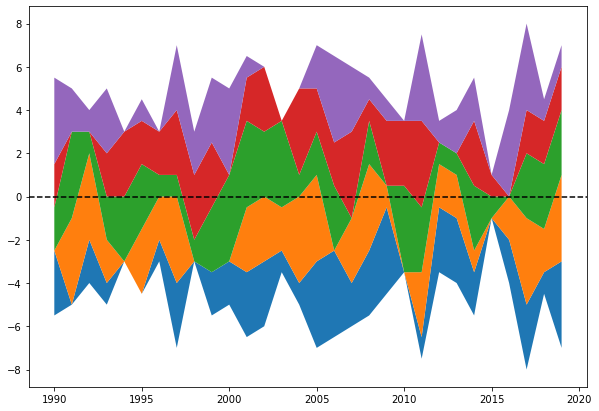

In [28]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.stackplot(x, y, baseline="sym")
ax.axhline(0, color="black", ls="--");

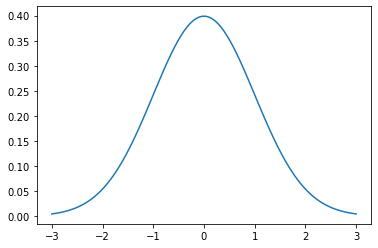

In [29]:
grid = np.linspace(-3, 3, num=100)
plt.plot(grid, stats.norm.pdf(grid));

In [30]:
def gaussian_smooth(x, y, sd):
    weights = np.array([stats.norm.pdf(x, m, sd) for m in x])
    weights = weights / weights.sum(1)
    return (weights * y).sum(1)

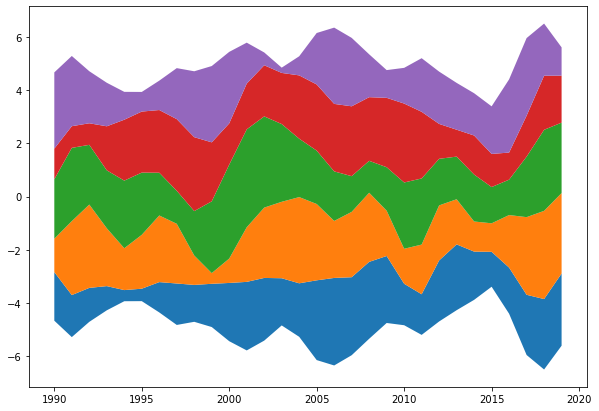

In [31]:
fig, ax = plt.subplots(figsize=(10, 7))
y_smoothed = [gaussian_smooth(x, y_, 1) for y_ in y]
ax.stackplot(x, y_smoothed, baseline="sym");

In [32]:
def gaussian_smooth(x, y, grid, sd):
    weights = np.transpose([stats.norm.pdf(grid, m, sd) for m in x])
    weights = weights / weights.sum(0)
    return (weights * y).sum(1)

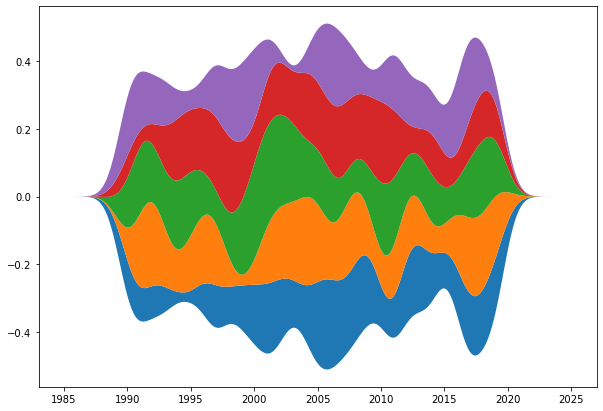

In [33]:
fig, ax = plt.subplots(figsize=(10, 7))
grid = np.linspace(1985, 2025, num=500)
y_smoothed = [gaussian_smooth(x, y_, grid, 1) for y_ in y]
ax.stackplot(grid, y_smoothed, baseline="sym");

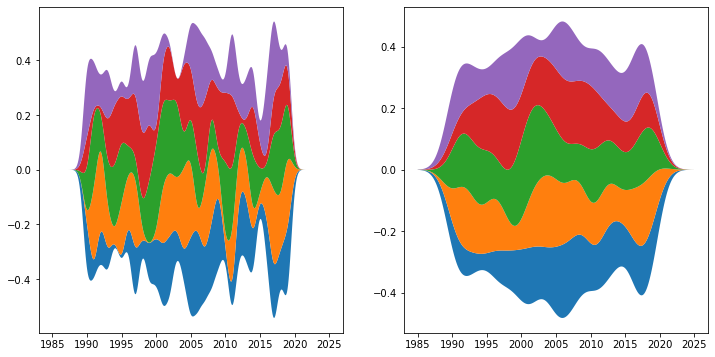

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# sd of 0.6
y_smoothed_1 = [gaussian_smooth(x, y_, grid, 0.6) for y_ in y]
# sd of 1.5
y_smoothed_2 = [gaussian_smooth(x, y_, grid, 1.5) for y_ in y]

ax[0].stackplot(grid, y_smoothed_1, baseline="sym")
ax[1].stackplot(grid, y_smoothed_2, baseline="sym");

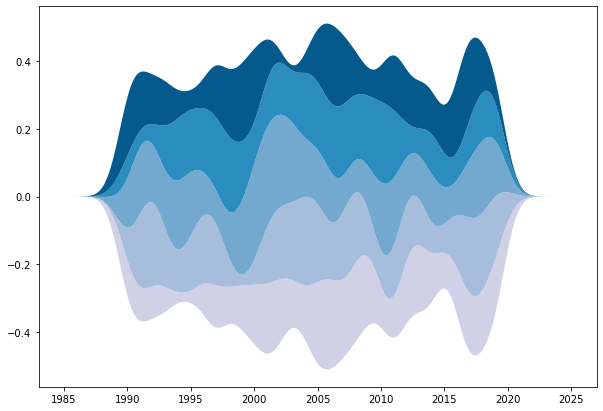

In [35]:
COLORS = ["#D0D1E6", "#A6BDDB", "#74A9CF", "#2B8CBE", "#045A8D"]
fig, ax = plt.subplots(figsize=(10, 7))
# Colors in the `COLORS` list are assigned to individual areas from bottom to top.
ax.stackplot(grid, y_smoothed, colors=COLORS, baseline="sym");